<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20Denoiser/05_three_factor_noisy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN regime 1 (Denoiser) · Three-factor noisy (cos≈0.01)
Recreate a binarized MNIST image (P≈1.01M ConvAE); loss = per-pixel BCE, metric = pixel-accuracy.

## Step 0 — Setup

In [1]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config

In [2]:
METHOD = 'three_factor_noisy'
SIGMA = 1e-2
TARGET_COS = 0.01   # M chosen so cos(g_hat, grad) ~ this
CHUNK_PROBES = 256
LR_LOCAL = 0.05
MOMENTUM = 0.9
CLIP_GRAD_NORM = 1.0
METHOD_CFG = dict(SIGMA=SIGMA, TARGET_COS=TARGET_COS, CHUNK_PROBES=CHUNK_PROBES, LR_LOCAL=LR_LOCAL, MOMENTUM=MOMENTUM, CLIP_GRAD_NORM=CLIP_GRAD_NORM)

CORRUPT_SIGMA = 0.5   # denoiser: input = image + N(0,sigma^2), target = clean
DRIVE_SUBDIR = 'Section7_r1_denoiser'


# =============================== CONFIG (shared across the 5 methods) ===============================
# CNN autoencoder (~1.01M) recreates a binarized MNIST image. Same P as §6/§8 -> cos sweep comparable.
CONV_C, LATENT = 48, 98           # channels / bottleneck; build cell prints exact P (target ~1.01M)
TIME_BUDGET_HOURS = 2.0
BATCH             = 128
SEED              = 0
EVAL_N, EVAL_BATCH = 4096, 1024
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True


SMOKE = False
if SMOKE:                                     # ~20-40 s CPU check
    CONV_C, LATENT = 8, 16
    TIME_BUDGET_HOURS = 30/3600
    LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 1, 2, 999, 1
    EVAL_N, EVAL_BATCH, USE_DRIVE = 512, 512, False
# ===================================================================================================

## Step 1 — Storage (Drive) + paths

In [3]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Mounted at /content/drive
storing under: /content/drive/MyDrive/Section7_r1_denoiser


## Step 2 — Model (CNN autoencoder)

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 28x28 logits.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=48, latent=98):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(1, conv_c, 3, stride=2, padding=1), nn.ReLU(),   # 28 -> 14
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),  # 14 -> 7
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 7 * 7, latent)
        self.fc2 = nn.Linear(latent, c2 * 7 * 7)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),               # 7 -> 14
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),               # 14 -> 28
            nn.Conv2d(conv_c, 1, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 7, 7)
        return self.dec(h2)                                            # (B,1,28,28) logits

## Step 3 — Data (binarized MNIST)

In [5]:
import torchvision
_tr = torchvision.datasets.MNIST('./data', train=True,  download=True)
_te = torchvision.datasets.MNIST('./data', train=False, download=True)
Xtr = (_tr.data.float()/255.0 > 0.5).float().unsqueeze(1).to(device)   # (60000,1,28,28) in {0,1}
Xte_all = (_te.data.float()/255.0 > 0.5).float().unsqueeze(1).to(device)
if SMOKE:
    Xtr, Xte_all = Xtr[:2000], Xte_all[:512]

def _corrupt(x):
    return x + CORRUPT_SIGMA * torch.randn_like(x) if CORRUPT_SIGMA > 0 else x

torch.manual_seed(SEED)                                                # reproducible eval corruption
Xte_tgt = Xte_all[:EVAL_N]
Xte_in  = _corrupt(Xte_tgt)
_bg = 1.0 - Xte_tgt.mean().item()                                      # all-background pixel-accuracy baseline

def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    xb = Xtr[idx]
    return _corrupt(xb), xb                                            # (input, clean target)
print(f'binarized MNIST | train {tuple(Xtr.shape)} | corrupt sigma={CORRUPT_SIGMA} | all-background pixel-acc baseline={_bg:.3f}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


binarized MNIST | train (60000, 1, 28, 28) | corrupt sigma=0.5 | all-background pixel-acc baseline=0.876


## Step 4 — Build + budget

In [6]:
torch.manual_seed(SEED)
model = ConvAE(CONV_C, LATENT).to(device)
P = sum(p.numel() for p in model.parameters())
Mstar = math.ceil((P + 1) / 3)
if METHOD.startswith('three_factor'):
    M = max(1, round(TARGET_COS**2 * (P + 1) / (1 - TARGET_COS**2)))
    got = (M / (M + P + 1))**0.5
    print(f'target cos = {TARGET_COS} -> M = {M:,} probes/step (actual cos = {got:.4f}); M*(cos=0.5) = {Mstar:,}')
else:
    M = 0
print(f'METHOD = {METHOD} | ConvAE P = {P:,} | conv_c={CONV_C} latent={LATENT}')
CFG = dict(METHOD=METHOD, SEED=SEED, CONV_C=CONV_C, LATENT=LATENT, BATCH=BATCH, CORRUPT_SIGMA=CORRUPT_SIGMA,
           TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)
if METHOD.startswith('three_factor'):
    CFG['M'] = M
assert P < 3_000_000, 'ConvAE too large for a from-scratch three-factor run (cost ~ P^2 at the clean budget).'

target cos = 0.01 -> M = 101 probes/step (actual cos = 0.0100); M*(cos=0.5) = 336,930
METHOD = three_factor_noisy | ConvAE P = 1,010,787 | conv_c=48 latent=98


## Step 5 — Probe estimator (vmap antithetic, BCE)

In [7]:
from torch.func import functional_call, vmap
base_buffers = {k: v.detach() for k, v in model.named_buffers()}       # none (no BN) -> {}

def get_params(m):
    return {k: v.detach().clone() for k, v in m.named_parameters()}

def loss_at(params, x, y):
    return F.binary_cross_entropy_with_logits(functional_call(model, (params, base_buffers), (x,)), y)

_vloss = vmap(loss_at, in_dims=(0, None, None))

def estimate_grad(params, x, y, M, sigma, chunk):
    g = {k: torch.zeros_like(v) for k, v in params.items()}
    done = 0
    while done < M:
        m = min(chunk, M - done)
        xi = {k: torch.randn((m,) + v.shape, device=v.device, dtype=v.dtype) for k, v in params.items()}
        pp = {k: params[k].unsqueeze(0) + sigma * xi[k] for k in params}
        pm = {k: params[k].unsqueeze(0) - sigma * xi[k] for k in params}
        score = (_vloss(pp, x, y) - _vloss(pm, x, y)) / (2 * sigma)
        for k in params:
            g[k] += torch.tensordot(score, xi[k], dims=([0], [0]))
        done += m
    return {k: g[k] / M for k in g}

## Step 6 — Trainer

In [8]:
params   = get_params(model)
velocity = {k: torch.zeros_like(v) for k, v in params.items()}
def forward_fn(x): return functional_call(model, (params, base_buffers), (x,))
def train_step():
    xb, yb = fresh_batch(BATCH)
    g = estimate_grad(params, xb, yb, M, SIGMA, CHUNK_PROBES)
    gn = math.sqrt(sum(float((v*v).sum()) for v in g.values()))
    if CLIP_GRAD_NORM and gn > CLIP_GRAD_NORM:
        s = CLIP_GRAD_NORM / (gn + 1e-12)
        for k in g: g[k].mul_(s)
    with torch.no_grad():
        for k in params:
            velocity[k] = MOMENTUM * velocity[k] + g[k]; params[k] -= LR_LOCAL * velocity[k]
        return F.binary_cross_entropy_with_logits(forward_fn(xb), yb).item()
def ckpt_state():      return {'params': params, 'velocity': velocity}
def load_ckpt_state(d):
    for k in params: params[k].copy_(d['params'][k]); velocity[k].copy_(d['velocity'][k])

## Step 7 — Eval / checkpoint / live-plot

In [9]:
@torch.no_grad()
def eval_metrics():
    bce_sum = 0.0; correct = 0; ne = 0
    for i in range(0, Xte_tgt.shape[0], EVAL_BATCH):
        logits = forward_fn(Xte_in[i:i+EVAL_BATCH]); tgt = Xte_tgt[i:i+EVAL_BATCH]
        bce_sum += F.binary_cross_entropy_with_logits(logits, tgt, reduction='sum').item()
        correct += ((logits > 0) == (tgt > 0.5)).sum().item()          # sigmoid(logit)>0.5 <=> logit>0
        ne += tgt.numel()
    return bce_sum/ne, correct/ne                                       # (mean BCE/pixel, pixel-accuracy)

In [10]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [11]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; te=[l[4] for l in logs]; acc=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train BCE'); ax[0].plot(hrs, te, 'o-', color='#C62828', label='test BCE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('BCE / pixel'); ax[0].set_title(f'{METHOD}: BCE vs time'); ax[0].legend()
    ax[1].plot(hrs, acc, 'o-', color='#1F3864')
    if '_bg' in dir(): ax[1].axhline(_bg, color='gray', ls='--', lw=1, label=f'all-bg {_bg:.2f}'); ax[1].legend()
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('pixel accuracy'); ax[1].set_title('pixel-acc vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_bce={last[4]:.4f} pixel_acc={last[5]:.4f}')

## Step 8 — Train (equal wall-clock, heartbeat) + save results

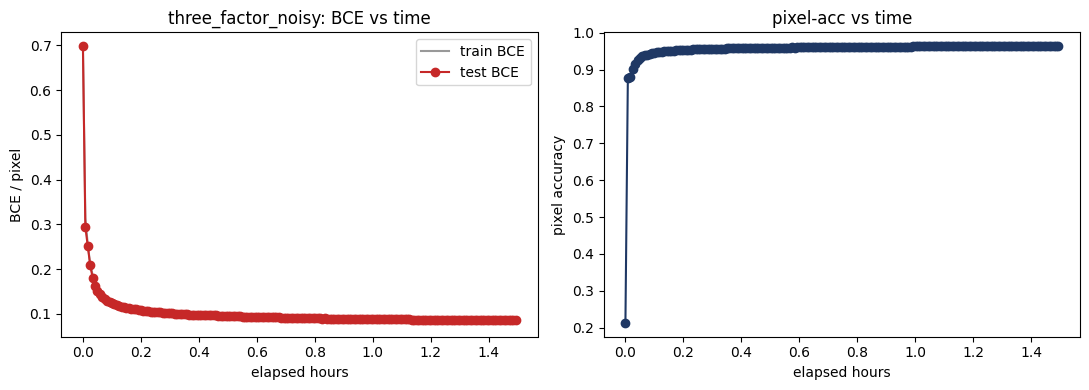

[h=1.49] step=49,768 test_bce=0.0867 pixel_acc=0.9633
[three_factor_noisy] h=1.50 step=50,020 train=0.0878 test_bce=0.0867 pixel_acc=0.9633
[three_factor_noisy] h=1.52 step=50,576 train=0.0887 test_bce=0.0866 pixel_acc=0.9634
[three_factor_noisy] h=1.53 step=51,132 train=0.0826 test_bce=0.0866 pixel_acc=0.9634
[three_factor_noisy] h=1.55 step=51,688 train=0.0916 test_bce=0.0866 pixel_acc=0.9635
[three_factor_noisy] h=1.57 step=52,244 train=0.0825 test_bce=0.0866 pixel_acc=0.9634
[three_factor_noisy] h=1.58 step=52,800 train=0.0870 test_bce=0.0866 pixel_acc=0.9634
[three_factor_noisy] h=1.60 step=53,356 train=0.0874 test_bce=0.0865 pixel_acc=0.9635
[three_factor_noisy] h=1.62 step=53,912 train=0.0857 test_bce=0.0865 pixel_acc=0.9635
[three_factor_noisy] h=1.63 step=54,468 train=0.0858 test_bce=0.0866 pixel_acc=0.9633
[three_factor_noisy] h=1.65 step=55,024 train=0.0841 test_bce=0.0866 pixel_acc=0.9635
[three_factor_noisy] h=1.67 step=55,580 train=0.0879 test_bce=0.0864 pixel_acc=0.9635


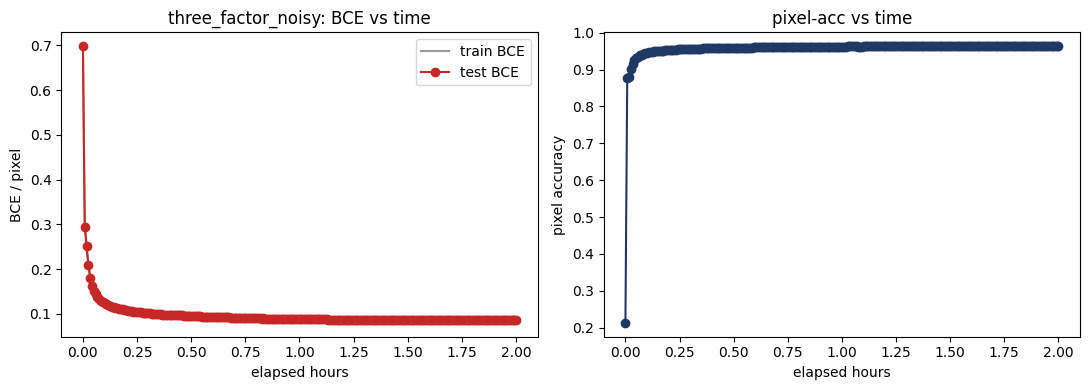

[h=2.00] step=66,657 test_bce=0.0866 pixel_acc=0.9634
wrote /content/drive/MyDrive/Section7_r1_denoiser/results/three_factor_noisy.json
DONE three_factor_noisy: 66,657 steps, 2.00h, pixel-acc 0.9634 (bg 0.876), best BCE 0.0863


In [12]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; acc = [l[5] for l in logs]
    summary = dict(initial_bce=logs[0][4], final_bce=logs[-1][4], best_bce=min(te),
                   final_acc=logs[-1][5], best_acc=max(acc), bg_baseline=_bg)
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, samples=step*BATCH, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], samples=[l[2] for l in logs],
                          train_bce=[l[3] for l in logs], test_bce=te, test_acc=acc),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        b0, a0 = eval_metrics(); logs.append((elapsed0, step, 0, b0, b0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            bce, acc = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, bce, acc)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.4f} test_bce={L[4]:.4f} pixel_acc={L[5]:.4f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    bce, acc = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, bce, acc))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, pixel-acc {acc:.4f} (bg {_bg:.3f}), best BCE {min(l[4] for l in logs):.4f}')

run()

## How to run
- `SMOKE=True` first, then `False` → Runtime → Run all.
- Equal wall-clock; heartbeat ~60 s; disconnect-safe (auto-resume); writes `results/<method>.json`. Pixel-accuracy has an all-background floor (~0.87); methods must beat that. Compare in `06_compare_results.ipynb`.